In [6]:
from mipt import *

In [ ]:
backend = AerSimulator(device='GPU')

n=18
d=2*n
p=0.17
realisations = 1

gmns = []
for _ in range(realisations):
    print("Constructing and running circuit...")
    qc = random_mipt_1d(n, d, p, closed=True)
    qc.save_statevector(label='final_state')
    transpiled_qc = transpile(qc, backend)

    result = backend.run(transpiled_qc).result()

    saved_state = result.data(0)['final_state']

    rho = partial_trace(saved_state, [i for i in range(n-3)])
    print("Finding GMN...")
    gmns.append(gmn(rho))

print(np.mean(gmns), "+/-", np.std(gmns)/np.sqrt(realisations))

Constructing and running circuit...


: 

Simulating p = 0.1
Simulating p = 0.1375
Simulating p = 0.175
Simulating p = 0.2125
Simulating p = 0.25


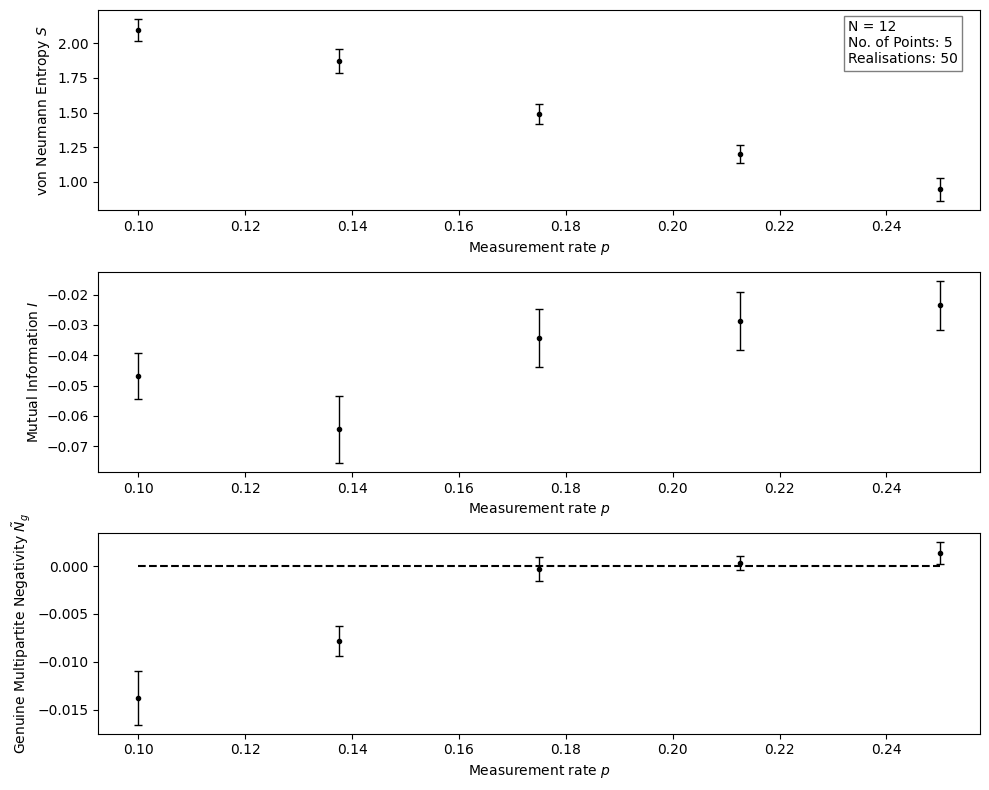

In [ ]:
n=14
d=2*n
res = 5
realisations = 50
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run(n=n, d=d, res=res, realisations=realisations, p_min=0.1, p_max=0.25)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"N = {n}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

In [ ]:
x = 4
y = 4
d=4*(x*y)
res = 5
realisations = 5
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_2d(x=x, y=y, d=d, res=res, realisations=realisations, p_min=0.0, p_max=0.5)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"x = {x}, y = {y}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

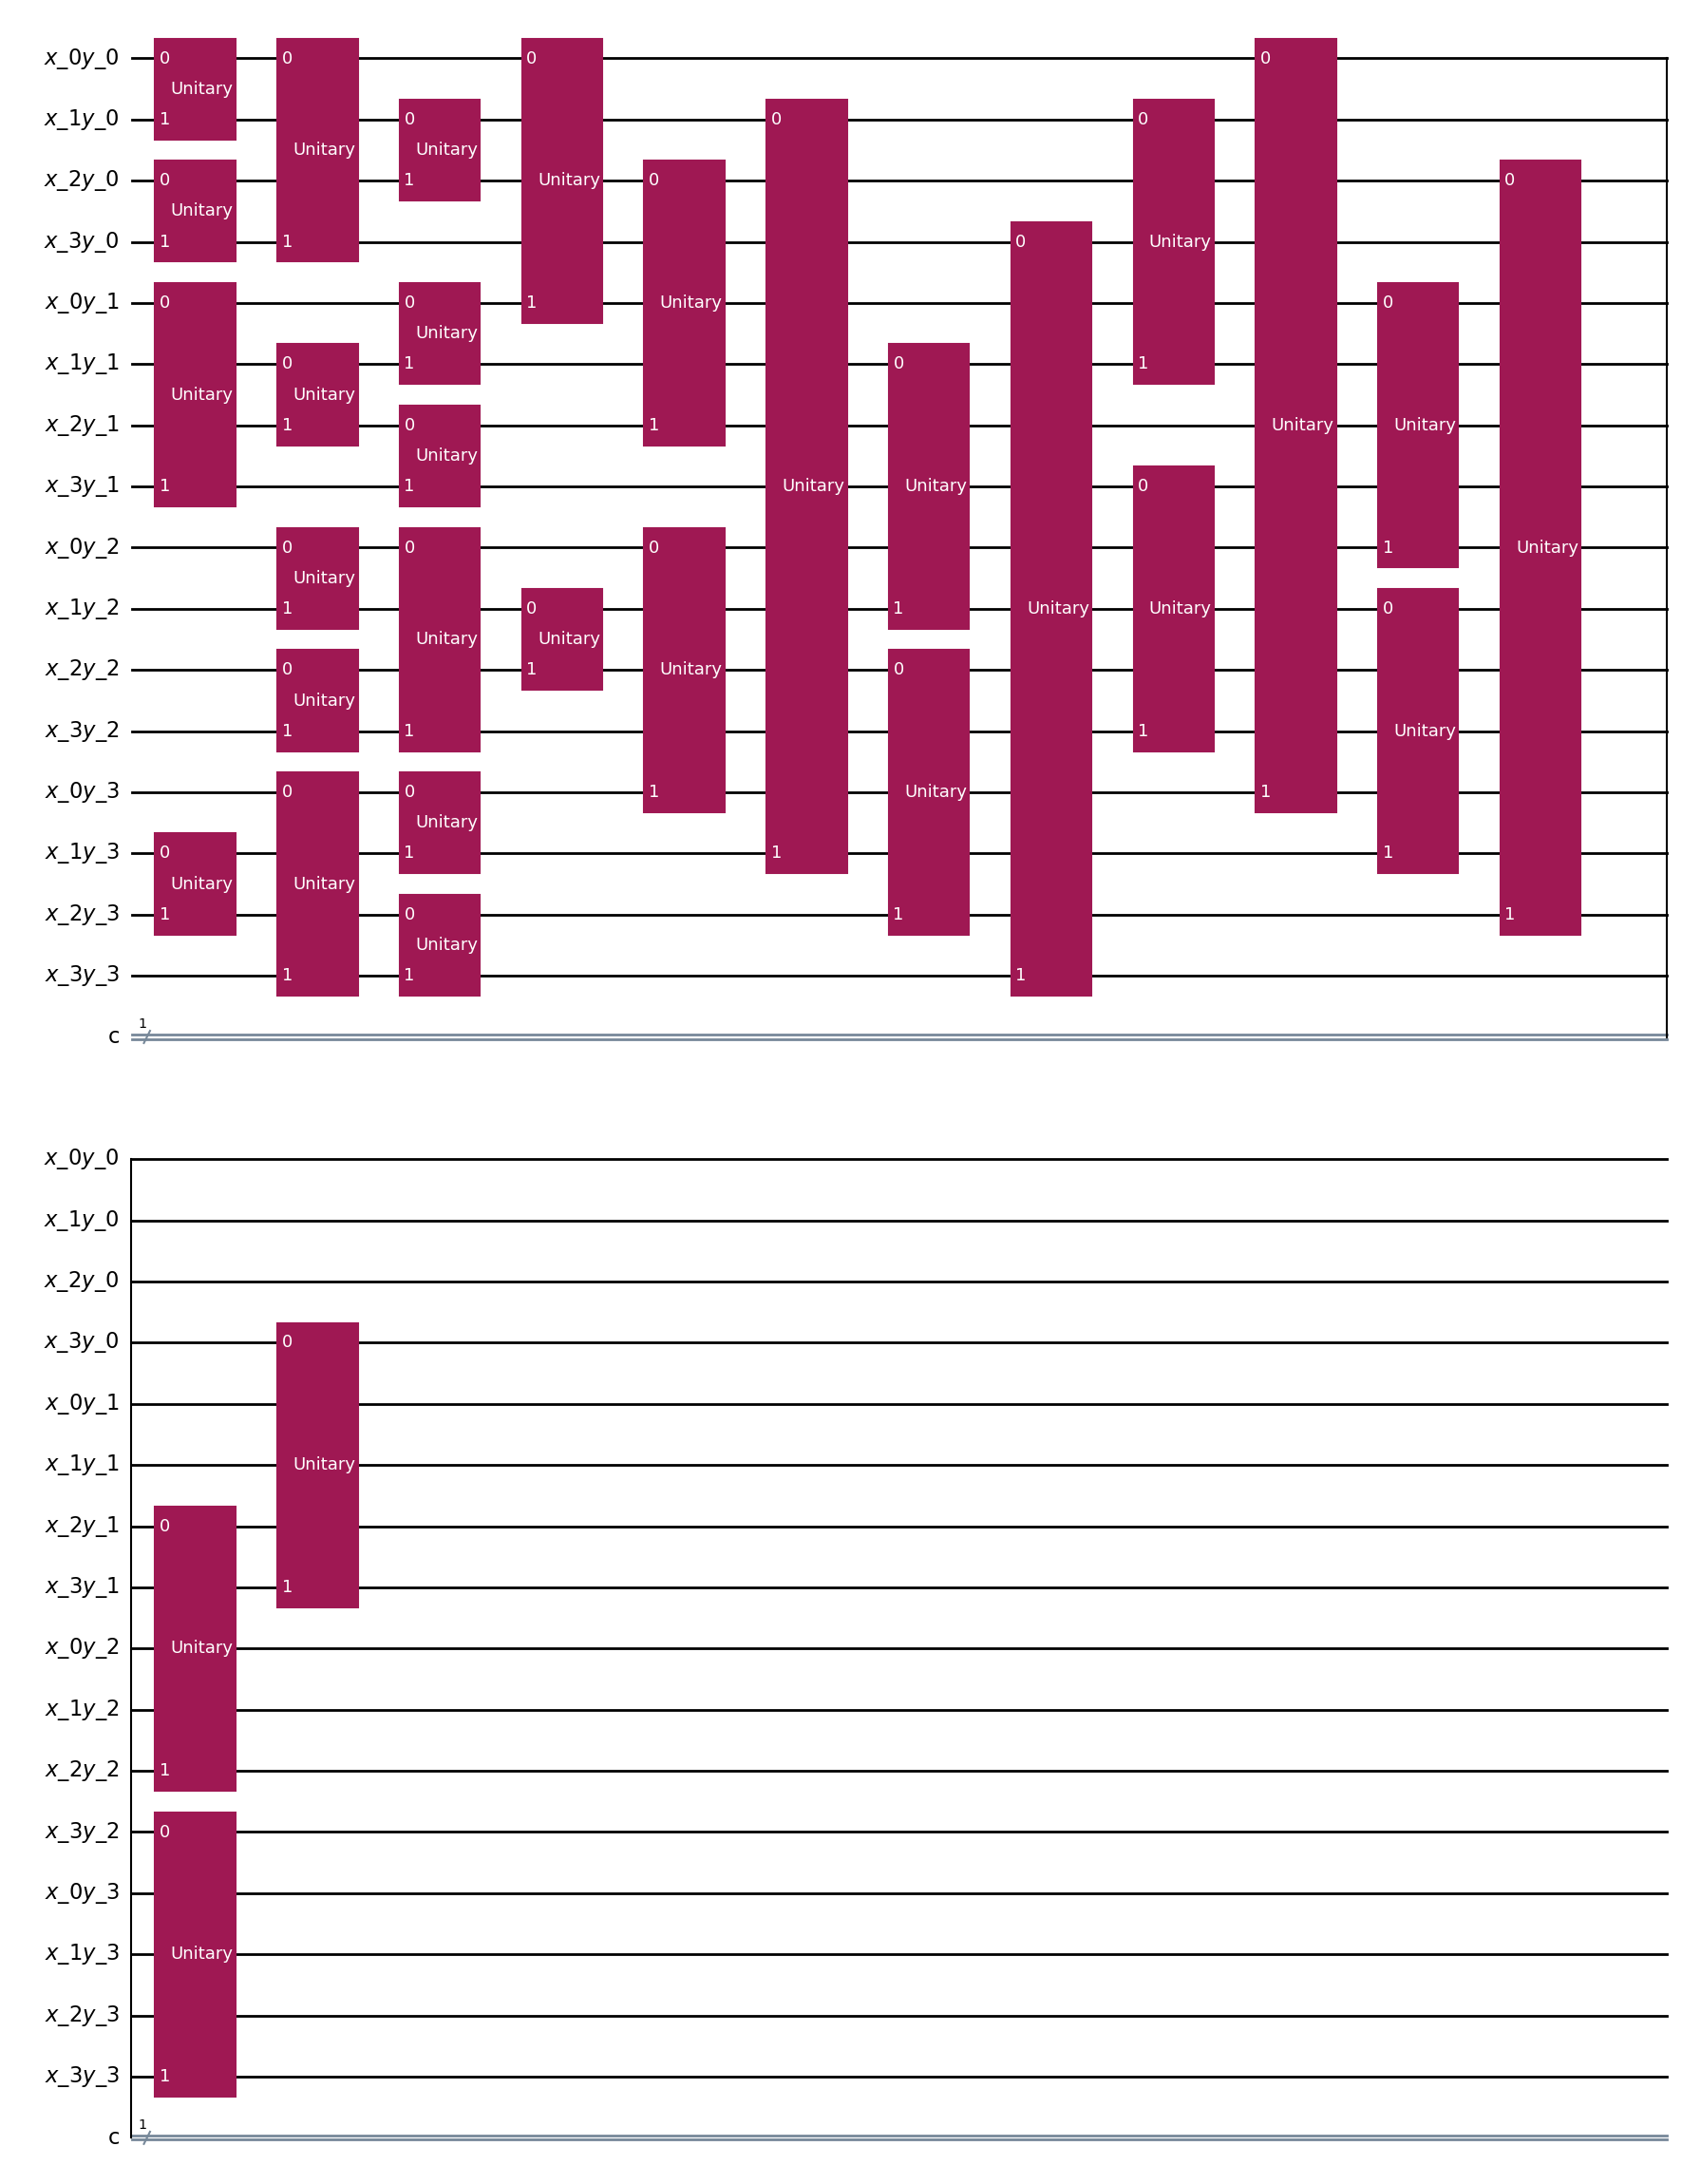

: 

In [ ]:
from mipt import *

qc = random_mipt_2d(x=4, y=4, d=4, p=0)
qc.draw('mpl')
# qc.save_statevector(label='final_state')
# backend = AerSimulator(device='GPU')
# transpiled_qc = transpile(qc, backend)
# result = backend.run(transpiled_qc).result()
# saved_state = result.data(0)['final_state']

# rho = partial_trace(saved_state, [i for i in range(4*4 - 3)])
# print(gmn(rho))

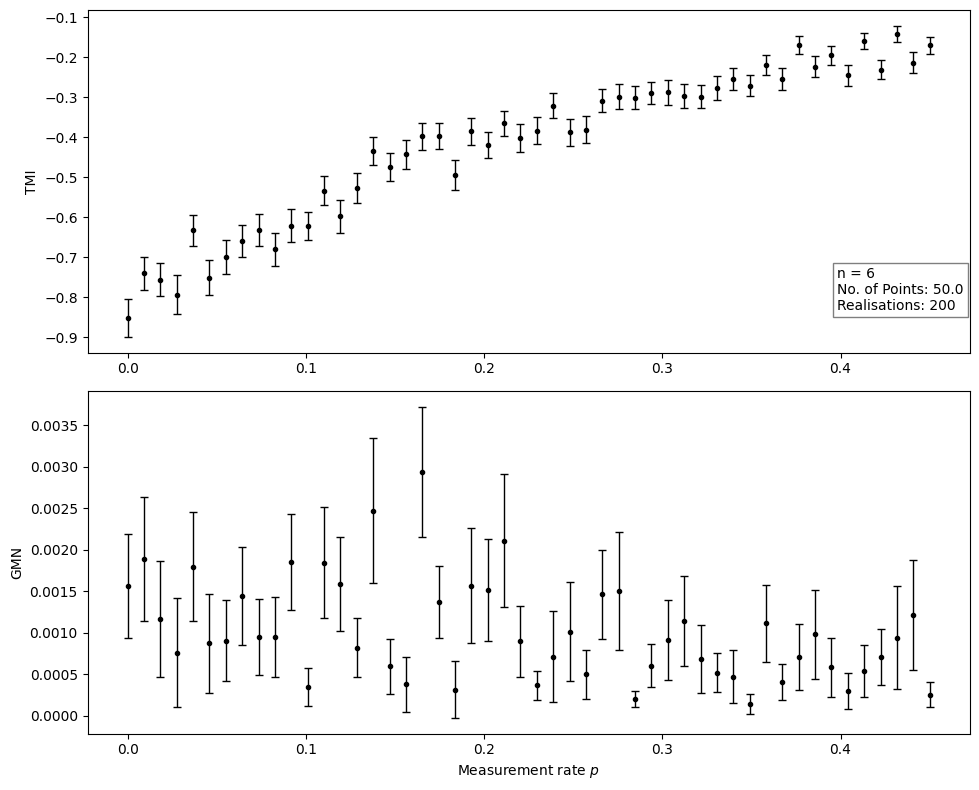

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_csv('data.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
tmi_values = data_array[1]
gmn_values = data_array[2]

realizations = 0
lowest_p = ps[0]
for i in range(len(ps)):
    if ps[i] != lowest_p:
        break
    realizations += 1

ps_unique = list(set(ps))
tmi_means = []
tmi_stds = []
gmn_means = []
gmn_stds = []
for p in ps_unique:
    tmi_values_for_p = [tmi for tmi, p_val in zip(tmi_values, ps) if p_val == p]
    tmi_means.append(np.mean(tmi_values_for_p))
    tmi_stds.append(np.std(tmi_values_for_p)/np.sqrt(realizations))
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p)/np.sqrt(realizations))

fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(10, 8))
ax1.errorbar(ps_unique, tmi_means, yerr=tmi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('TMI')
ax2.set_ylabel('GMN')

df = pd.read_csv('info.csv')
data_array = df.to_numpy().transpose()
n = data_array[0][0]
periods = data_array[1][0]
realizations = data_array[2][0]
res = data_array[3][0]
p_min = data_array[4][0]
p_max = data_array[5][0]
props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.25, f"n = {n}\nPeriods = {periods}\nRealisations = {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

fig.tight_layout()

In [13]:
import cvxpy as cp
import numpy as np
from itertools import combinations


# ------------------------------------------------------------
# Convert Qiskit DensityMatrix / Statevector to numpy matrix
# ------------------------------------------------------------
def to_numpy_density_matrix(rho):
    rho = np.asarray(getattr(rho, "data", rho), dtype=complex)

    if rho.ndim == 1:  # statevector
        rho = np.outer(rho, rho.conj())

    return rho


# ------------------------------------------------------------
# Build partial transpose as a LINEAR MAP on vec(W)
# ------------------------------------------------------------
def partial_transpose_map(dims, sys):
    """
    Returns matrix PT such that:
        vec(W^T_sys) = PT @ vec(W)
    """
    d = int(np.prod(dims))
    dim2 = d * d

    PT = np.zeros((dim2, dim2), dtype=float)

    # basis element E_ij
    for i in range(d):
        for j in range(d):

            E = np.zeros((d, d))
            E[i, j] = 1.0

            # reshape into tensor form
            tensor = E.reshape(dims + dims)

            N = len(dims)
            axes = list(range(2 * N))

            for s in sys:
                axes[s], axes[s + N] = axes[s + N], axes[s]

            pt = tensor.transpose(axes).reshape(d, d)

            col = i * d + j
            PT[:, col] = pt.flatten()

    return PT


# ------------------------------------------------------------
# GMNN SDP
# ------------------------------------------------------------
def gmnn_sdp(rho, dims, k_minus_1=2, verbose=True):
    """
    GMNN witness SDP relaxation.

    Parameters:
    - rho: density matrix (Qiskit or numpy)
    - dims: subsystem dimensions, e.g. [2,2,2]
    - k_minus_1: max hyperedge size (2 = bipartite resources)
    """

    rho = to_numpy_density_matrix(rho)
    d = rho.shape[0]

    parties = list(range(len(dims)))

    # --------------------------------------------------------
    # Build allowed subsystem structure (hyperedges)
    # --------------------------------------------------------
    edges = []
    for r in range(1, k_minus_1 + 1):
        edges += list(combinations(parties, r))

    # --------------------------------------------------------
    # SDP variable: entanglement witness
    # --------------------------------------------------------
    W = cp.Variable((d, d), hermitian=True)

    constraints = []

    # --------------------------------------------------------
    # Constraint 1: upper bound (stability / normalization)
    # --------------------------------------------------------
    constraints += [W << np.eye(d)]

    # --------------------------------------------------------
    # Constraint 2: positivity of partial transposes
    # (network-relaxed PPT constraints)
    # --------------------------------------------------------
    W_vec = cp.vec(W, order="C")

    for S in edges:
        PT = partial_transpose_map(dims, S)

        W_pt = cp.reshape(PT @ W_vec, (d, d), order="C")

        constraints += [W_pt >> 0]

    # --------------------------------------------------------
    # Objective: GMNN witness value
    # --------------------------------------------------------
    objective = cp.Minimize(cp.real(cp.trace(rho @ W)))

    prob = cp.Problem(objective, constraints)

    prob.solve(solver=cp.MOSEK)

    gmnn_value = -prob.value

    return gmnn_value, W.value

n=8
d=2*n
p=0.17
qc = random_mipt_1d(n, d, p, closed=True)
qc.save_statevector(label='final_state')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc).result()
saved_state = result.data(0)['final_state']
sub_m = partial_trace(saved_state, [i for i in range(n-3)])

gmnn_value, W_opt = gmnn_sdp(sub_m, dims=[2,2,2], k_minus_1=2)
print("GMNN value:", gmnn_value)

GMNN value: 0.10796417856881455


Simulating p = 0.05
Simulating p = 0.125
Simulating p = 0.2
Simulating p = 0.27499999999999997
Simulating p = 0.35


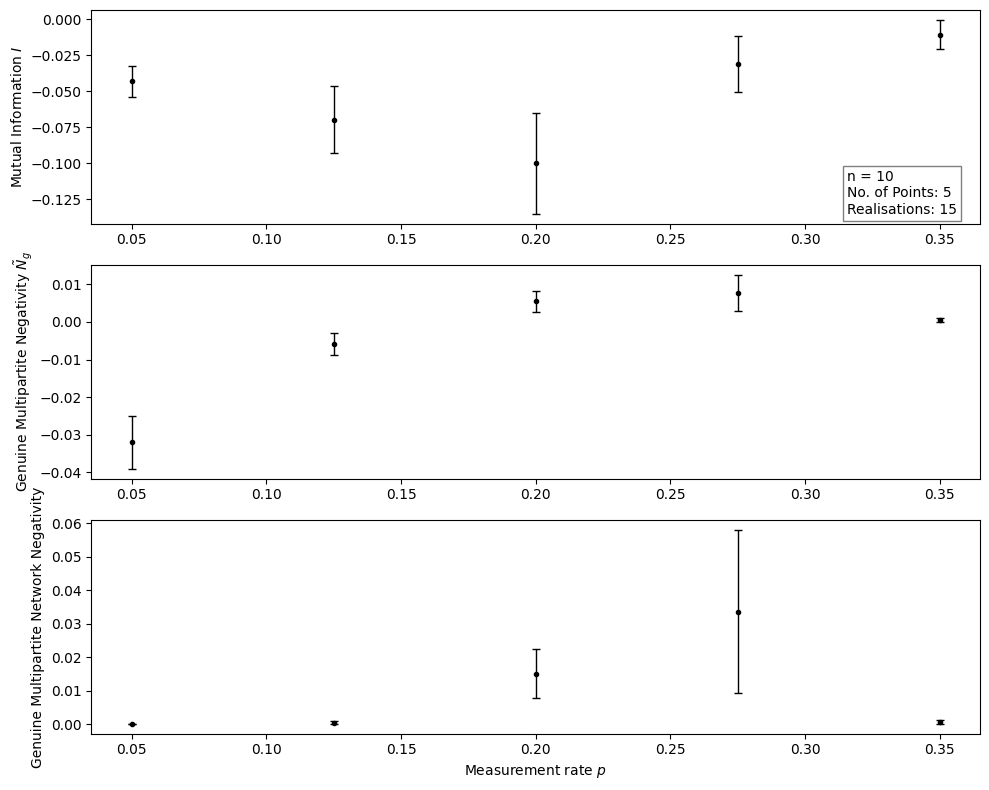

In [10]:
from mipt import *

n=10
d=2*n
res = 5
realisations = 15
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds, gmnns, gmnn_stds = run_1d(n=n, d=d, res=res, 
                                                                            realisations=realisations, p_min=0.05, p_max=0.35)


fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))
props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.25, f"n = {n}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmnns, yerr=gmnn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_ylabel('Mutual Information $I$')
ax2.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel('Genuine Multipartite Network Negativity')
plt.tight_layout()

Simulating p = 0.0
Simulating p = 0.1111111111111111
Simulating p = 0.2222222222222222
Simulating p = 0.3333333333333333
Simulating p = 0.4444444444444444
Simulating p = 0.5555555555555556
Simulating p = 0.6666666666666666
Simulating p = 0.7777777777777777
Simulating p = 0.8888888888888888
Simulating p = 1.0


<ErrorbarContainer object of 3 artists>

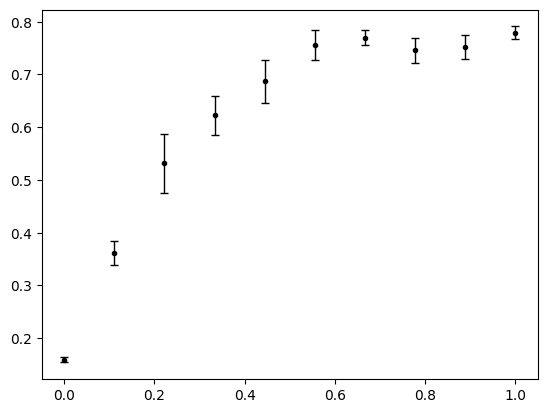

In [5]:
import numpy as np
import cvxpy as cp

# -----------------------------
# Utilities: random unitaries
# -----------------------------
def random_unitary(n):
    """Haar-random unitary via QR decomposition."""
    x = (np.random.randn(n, n) + 1j*np.random.randn(n, n)) / np.sqrt(2)
    q, r = np.linalg.qr(x)
    d = np.diag(r)
    ph = d / np.abs(d)
    return q * ph


def kron_list(mats):
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out


# -----------------------------
# Generate "UQN-like" pure states
# (approximation of 2-layer circuits)
# -----------------------------
def generate_uqn_states(n_qubits, n_samples):
    dim = 2 ** n_qubits
    states = []

    for _ in range(n_samples):

        # ---- Layer 1: entangling blocks ----
        # (approximate k-partite unitaries by random full unitary on blocks)
        state = np.zeros(dim, dtype=complex)
        state[0] = 1.0

        U1 = random_unitary(dim)
        state = U1 @ state

        # ---- Layer 2: local unitaries ----
        local_ops = []
        for _ in range(n_qubits):
            local_ops.append(random_unitary(2))
        U2 = kron_list(local_ops)

        state = U2 @ state

        # density matrix
        rho = np.outer(state, np.conj(state))
        states.append(rho)

    return states


# -----------------------------
# Frobenius distance D(rho)
# -----------------------------
def uqn_distance(rho, uqn_states):

    N = len(uqn_states)
    rho = to_numpy_density_matrix(rho)
    d = rho.shape[0]

    # variables: convex weights
    w = cp.Variable(N)

    # construct sigma(w)
    sigma = sum(w[i] * uqn_states[i] for i in range(N))

    # Frobenius norm squared: Tr[(rho - sigma)^2]
    diff = rho - sigma
    objective = cp.Minimize(cp.sum_squares(cp.abs(diff)))

    constraints = [
        w >= 0,
        cp.sum(w) == 1
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    D = np.sqrt(prob.value)
    return D, w.value


n=8
d=2*n
ps = np.linspace(0, 1, 10)
res = 10

ds = []
d_stds = []
for p in ps:
    print("Simulating p =", p)
    this_ds = []
    for _ in range(res):
        qc = random_mipt_1d(n, d, p, closed=True)
        qc.save_statevector(label='final_state')
        transpiled_qc = transpile(qc, backend)
        result = backend.run(transpiled_qc).result()
        saved_state = result.data(0)['final_state']
        sub_m = partial_trace(saved_state, [i for i in range(n-3)])

        uqn_states = generate_uqn_states(n_qubits=3, n_samples=40)
        D, w = uqn_distance(sub_m, uqn_states)
        this_ds.append(D)
    ds.append(np.mean(this_ds))
    d_stds.append(np.std(this_ds)/np.sqrt(res))

plt.errorbar(ps, ds, yerr=d_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)

In [1]:
from mipt import *

n=12
d=2*n
res = 5
realisations = 15
ps, ents, ent_stds, mis, mi_stds, gmns, gmn_stds = run_1d(n=n, d=d, res=res, 
                                                        realisations=realisations, p_min=0.05, p_max=0.35, use_gpu=True)

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(10, 8))

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.85, 0.95, f"N = {n}\nNo. of Points: {res}\nRealisations: {realisations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.errorbar(ps, ents, yerr=ent_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax2.errorbar(ps, mis, yerr=mi_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax3.errorbar(ps, gmns, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
# ax3.hlines(0, ps[0], ps[-1], colors='black', linestyles='dashed')
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel('von Neumann Entropy $S$')
ax2.set_xlabel('Measurement rate $p$')
ax2.set_ylabel('Mutual Information $I$')
ax3.set_xlabel('Measurement rate $p$')
ax3.set_ylabel(r'Genuine Multipartite Negativity $\tilde{N}_g$')
plt.tight_layout()

AerError: 'Invalid option target_gpus'